# Wine Quality 시각화 대시보드 (Notebook)

이 노트북은 **UCI Wine Quality** 데이터 + 현재 저장된 모델(`models/model.joblib`)을 기준으로 분석/평가 결과를 시각화합니다.

- 분포(quality 0~10, 구간 라벨)
- 상관관계 히트맵
- 혼동행렬 + classification report
- 예측 확률 분포 / 오분류 사례
- 특성 중요도(랜덤포레스트) + permutation importance(선택)
- SHAP 요약 + 개별 샘플 설명


In [1]:
# 환경 설정 및 공통 유틸
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score,
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

ROOT = Path('..').resolve()
MODELS_DIR = (ROOT / 'models').resolve()
FIG_DIR = (ROOT / 'reports' / 'figures').resolve()
FIG_DIR.mkdir(parents=True, exist_ok=True)

URL_RED = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
URL_WHITE = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv'

def quality_to_class(q: int) -> int:
    # 학습 노트북과 동일: 0-4 poor, 5-6 normal, 7-10 good
    if q <= 4:
        return 0
    if q <= 6:
        return 1
    return 2

def load_artifacts():
    import joblib
    feature_order = json.loads((MODELS_DIR / 'feature_order.json').read_text())
    class_names = json.loads((MODELS_DIR / 'class_names.json').read_text())
    model = joblib.load(MODELS_DIR / 'model.joblib')
    scaler = joblib.load(MODELS_DIR / 'scaler.joblib')
    return feature_order, class_names, model, scaler

feature_order, class_names, model, scaler = load_artifacts()
feature_order, class_names

(['fixed acidity',
  'volatile acidity',
  'citric acid',
  'residual sugar',
  'chlorides',
  'free sulfur dioxide',
  'total sulfur dioxide',
  'density',
  'pH',
  'sulphates',
  'alcohol'],
 ['poor', 'normal', 'good'])

In [2]:
# 데이터 로드 + 라벨 생성
df = pd.concat([
    pd.read_csv(URL_RED, sep=';').assign(type='red'),
    pd.read_csv(URL_WHITE, sep=';').assign(type='white'),
], ignore_index=True)

df['quality_class'] = df['quality'].map(quality_to_class)
df['quality_label'] = df['quality_class'].map({0: 'poor(0-4)', 1: 'normal(5-6)', 2: 'good(7-10)'})

print('Shape:', df.shape)
print('Missing values:', int(df.isnull().sum().sum()))
df.head()

Shape: (6497, 15)
Missing values: 0


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type,quality_class,quality_label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,1,normal(5-6)
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red,1,normal(5-6)
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red,1,normal(5-6)
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red,1,normal(5-6)
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,1,normal(5-6)


/var/folders/ff/mrk8fkwn7tn0nmxmn_3lqxgw0000gn/T/ipykernel_88595/1556873348.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='quality_label', order=order, ax=axes[1], palette='viridis')


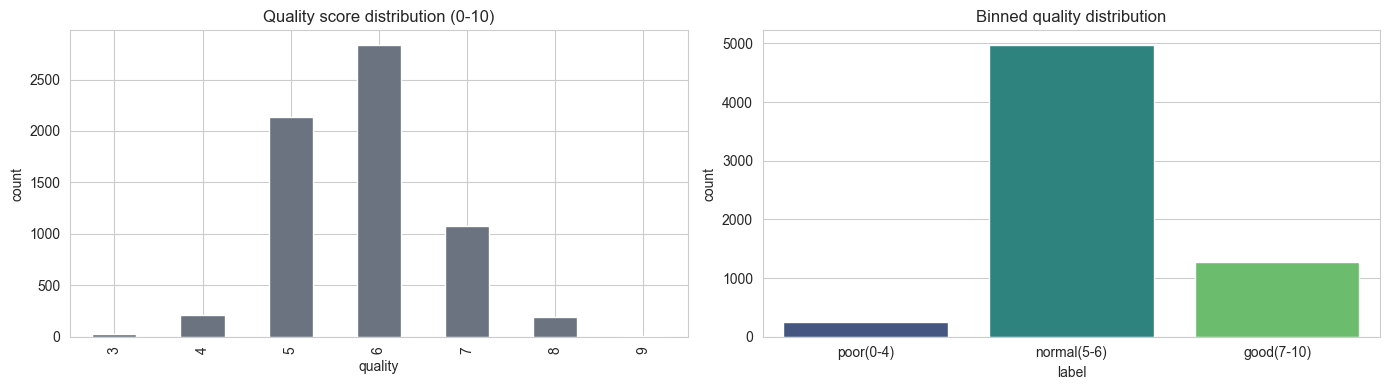

In [3]:
# A. 분포 시각화: quality(0~10) + 구간 라벨
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['quality'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#6b7280')
axes[0].set_title('Quality score distribution (0-10)')
axes[0].set_xlabel('quality')
axes[0].set_ylabel('count')

order = ['poor(0-4)', 'normal(5-6)', 'good(7-10)']
sns.countplot(data=df, x='quality_label', order=order, ax=axes[1], palette='viridis')
axes[1].set_title('Binned quality distribution')
axes[1].set_xlabel('label')
axes[1].set_ylabel('count')

plt.tight_layout()
plt.savefig(FIG_DIR / '01_quality_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

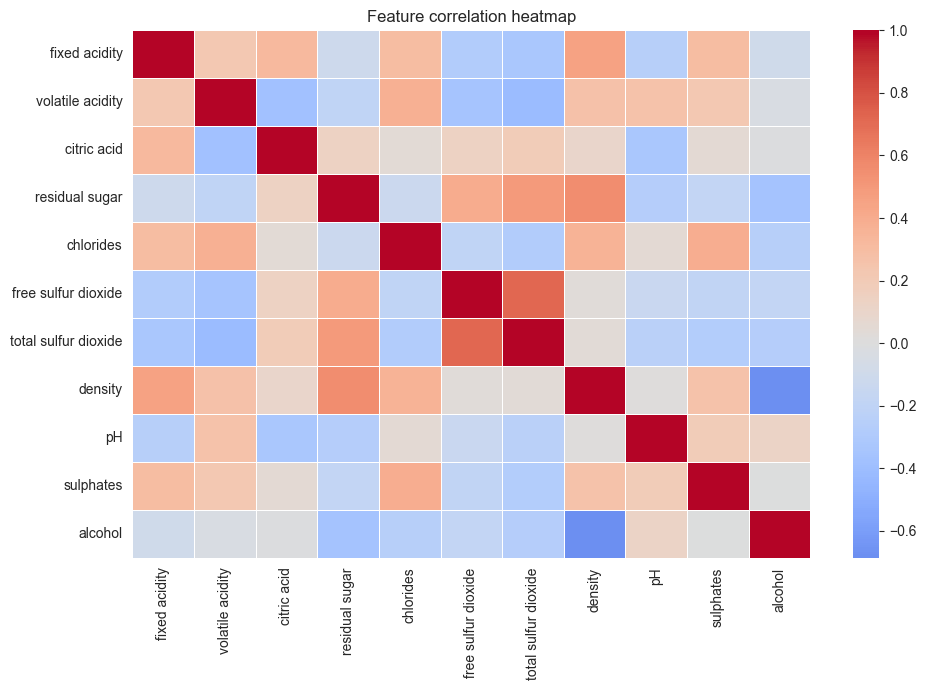

In [4]:
# B. 상관관계 히트맵 (입력 feature만)
corr = df[feature_order].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature correlation heatmap')
plt.tight_layout()
plt.savefig(FIG_DIR / '02_correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

In [5]:
# 데이터 분할 + 스케일 + 예측 (학습과 동일한 분할 설정)
X = df[feature_order]
y = df['quality_class']

_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 모델은 스케일된 입력으로 학습됨
X_test_scaled = scaler.transform(X_test)

y_pred = model.predict(X_test_scaled)
proba = model.predict_proba(X_test_scaled) if hasattr(model, 'predict_proba') else None

acc = accuracy_score(y_test, y_pred)
f1m = f1_score(y_test, y_pred, average='macro')
print(f'Accuracy: {acc:.4f} | F1-macro: {f1m:.4f}')

Accuracy: 0.8538 | F1-macro: 0.5899


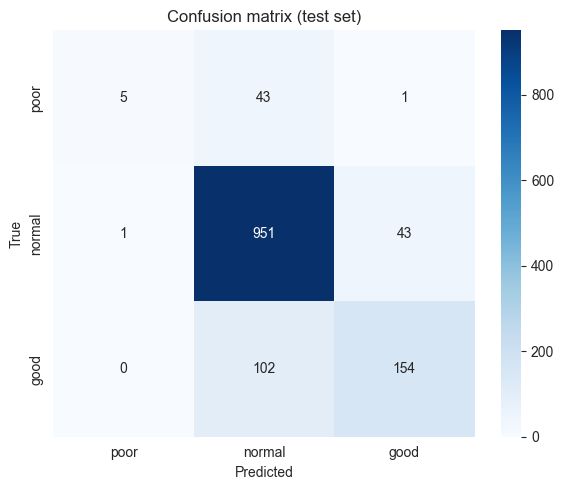

              precision    recall  f1-score   support

        poor     0.8333    0.1020    0.1818        49
      normal     0.8677    0.9558    0.9096       995
        good     0.7778    0.6016    0.6784       256

    accuracy                         0.8538      1300
   macro avg     0.8263    0.5531    0.5899      1300
weighted avg     0.8487    0.8538    0.8367      1300



In [6]:
# C. 혼동행렬 + classification report
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion matrix (test set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig(FIG_DIR / '03_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

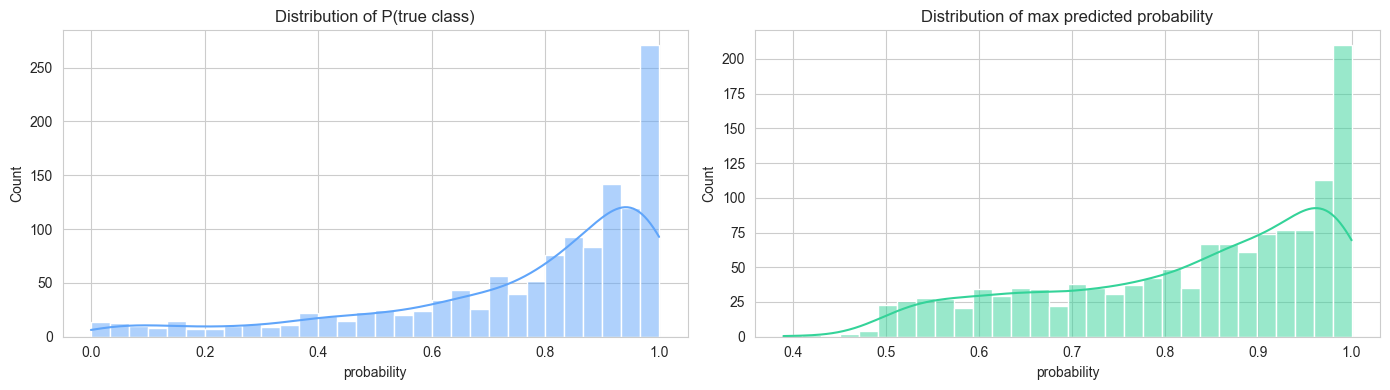

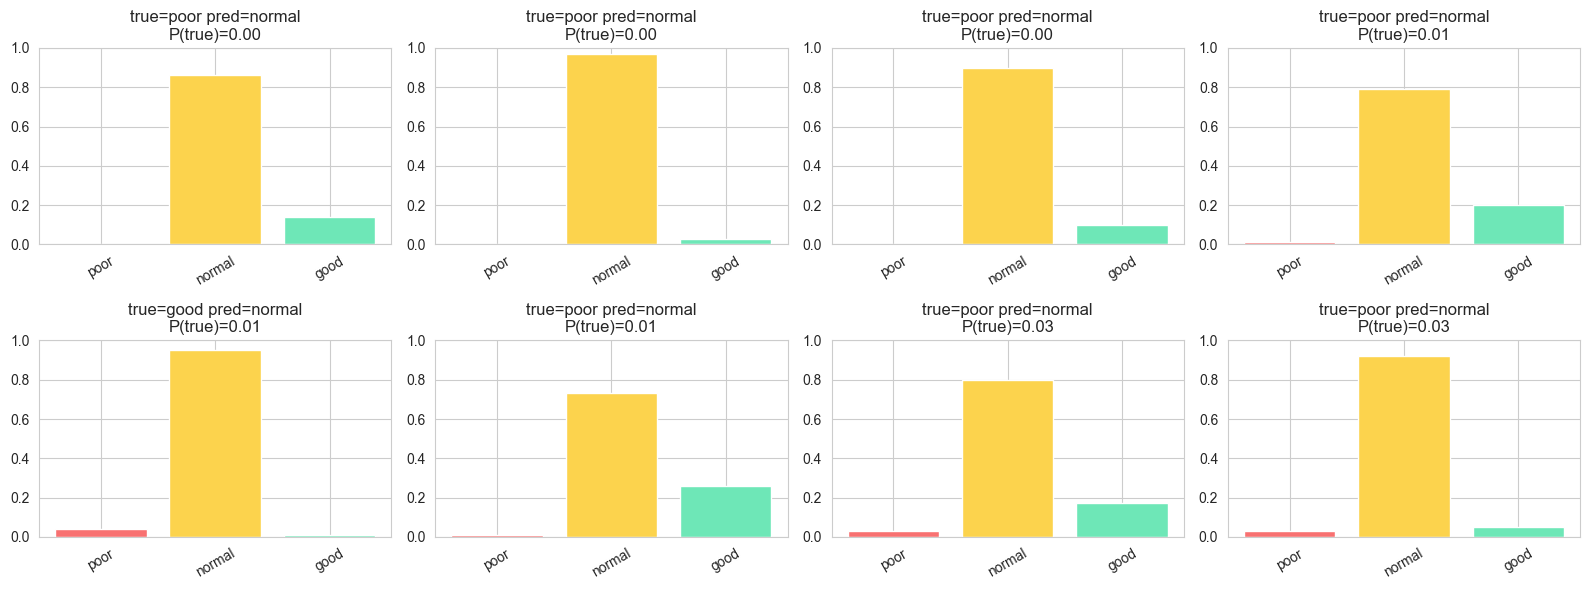

In [7]:
# D. 예측 확률 분포
if proba is None:
    print('Model has no predict_proba; skipping probability plots.')
else:
    proba_df = pd.DataFrame(proba, columns=class_names)
    proba_df['y_true'] = y_test.values
    proba_df['y_pred'] = y_pred
    proba_df['true_label'] = proba_df['y_true'].map({0: class_names[0], 1: class_names[1], 2: class_names[2]})
    proba_df['pred_label'] = proba_df['y_pred'].map({0: class_names[0], 1: class_names[1], 2: class_names[2]})
    # 정답 클래스 확률
    proba_df['p_true'] = proba_df.apply(lambda r: r[class_names[int(r['y_true'])]], axis=1)
    proba_df['p_max'] = proba_df[class_names].max(axis=1)
    proba_df['correct'] = (proba_df['y_true'] == proba_df['y_pred'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(proba_df['p_true'], bins=30, kde=True, ax=axes[0], color='#60a5fa')
    axes[0].set_title('Distribution of P(true class)')
    axes[0].set_xlabel('probability')

    sns.histplot(proba_df['p_max'], bins=30, kde=True, ax=axes[1], color='#34d399')
    axes[1].set_title('Distribution of max predicted probability')
    axes[1].set_xlabel('probability')

    plt.tight_layout()
    plt.savefig(FIG_DIR / '04_probability_distribution.png', bbox_inches='tight', dpi=150)
    plt.show()

    # 오분류 Top-k: 정답 클래스 확률이 낮은 순
    mis = proba_df[~proba_df['correct']].sort_values('p_true', ascending=True).head(8)
    if len(mis) == 0:
        print('No misclassifications in sample.')
    else:
        fig, axes = plt.subplots(2, 4, figsize=(16, 6))
        axes = axes.ravel()
        for ax, (_, r) in zip(axes, mis.iterrows()):
            ax.bar(class_names, [r[c] for c in class_names], color=['#f87171', '#fcd34d', '#6ee7b7'])
            ax.set_ylim(0, 1)
            ax.set_title(f"true={r['true_label']} pred={r['pred_label']}\nP(true)={r['p_true']:.2f}")
            ax.tick_params(axis='x', rotation=30)
        for ax in axes[len(mis):]:
            ax.axis('off')
        plt.tight_layout()
        plt.savefig(FIG_DIR / '05_misclassified_samples.png', bbox_inches='tight', dpi=150)
        plt.show()

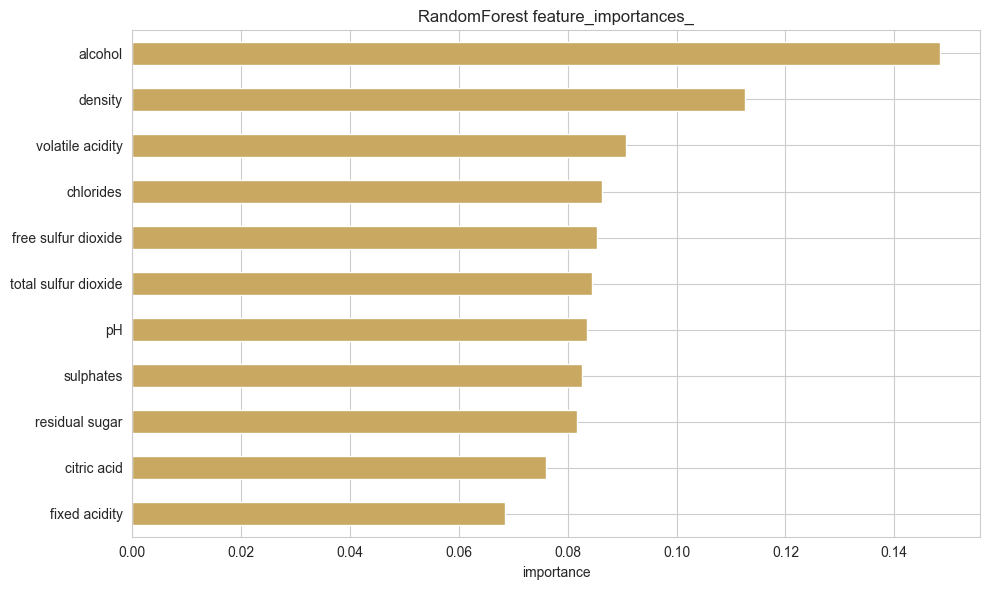

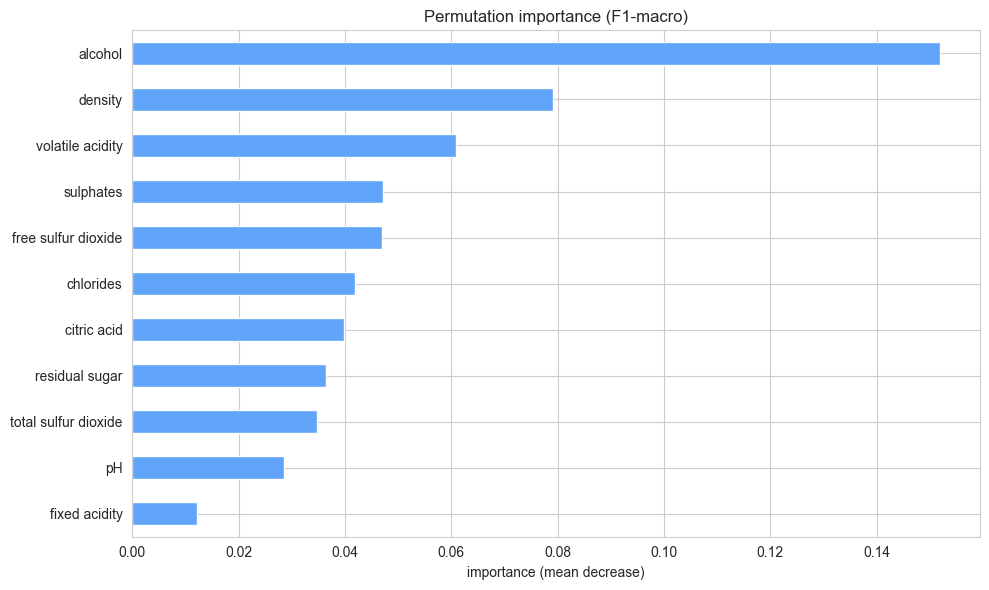

In [8]:
# E. 특성 중요도
if hasattr(model, 'feature_importances_'):
    imp = pd.Series(model.feature_importances_, index=feature_order).sort_values(ascending=True)
    plt.figure(figsize=(10, 6))
    imp.plot(kind='barh', color='#c9a962')
    plt.title('RandomForest feature_importances_')
    plt.xlabel('importance')
    plt.tight_layout()
    plt.savefig(FIG_DIR / '06_feature_importance.png', bbox_inches='tight', dpi=150)
    plt.show()
else:
    print('Model has no feature_importances_.')

# (선택) Permutation importance
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    model,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1_macro',
)
perm_imp = pd.Series(perm.importances_mean, index=feature_order).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
perm_imp.plot(kind='barh', color='#60a5fa')
plt.title('Permutation importance (F1-macro)')
plt.xlabel('importance (mean decrease)')
plt.tight_layout()
plt.savefig(FIG_DIR / '07_permutation_importance.png', bbox_inches='tight', dpi=150)
plt.show()

Computed SHAP values.
SHAP summary for class: poor


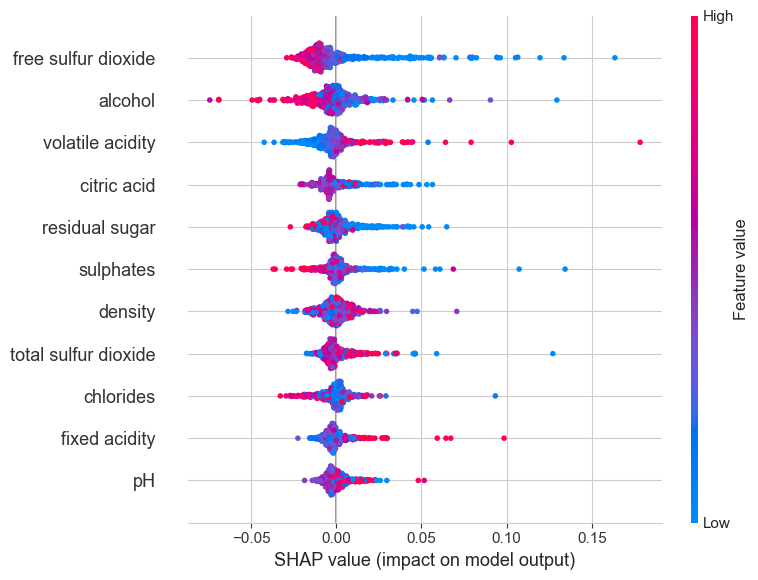

SHAP summary for class: normal


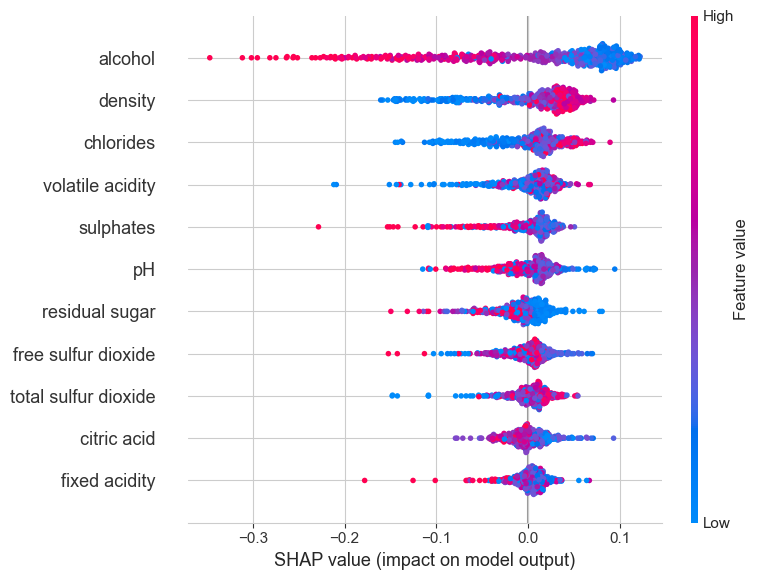

SHAP summary for class: good


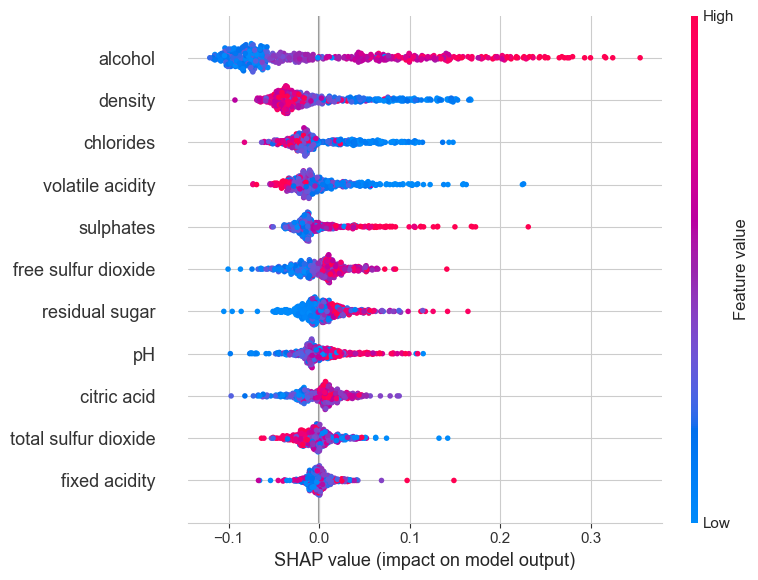

Explaining sample index: 2


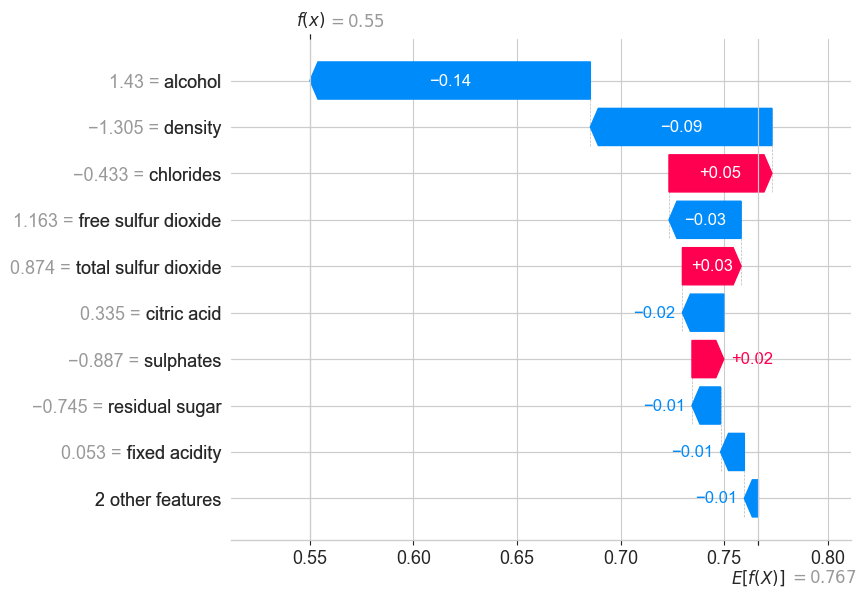

In [9]:
# F. SHAP (TreeExplainer)
# 주의: 이 모델은 스케일된 입력을 사용하므로, SHAP도 스케일된 입력 기준으로 계산됩니다.
import shap

X_shap = X_test_scaled
explainer = shap.TreeExplainer(model)

# 일부 샘플만 사용 (속도/메모리)
n = min(500, X_shap.shape[0])
X_shap_sub = X_shap[:n]
shap_values = explainer.shap_values(X_shap_sub)

print('Computed SHAP values.')

# shap 출력 형태는 구현/버전에 따라 다름:
# - list: 클래스별 (n, features)
# - ndarray: (n, features) 또는 (n, features, classes)

# 전체 요약
if isinstance(shap_values, list):
    for c, sv in enumerate(shap_values):
        print('SHAP summary for class:', class_names[c])
        shap.summary_plot(sv, features=X_shap_sub, feature_names=feature_order, show=True)
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    for c in range(shap_values.shape[2]):
        print('SHAP summary for class:', class_names[c])
        shap.summary_plot(shap_values[:, :, c], features=X_shap_sub, feature_names=feature_order, show=True)
else:
    shap.summary_plot(shap_values, features=X_shap_sub, feature_names=feature_order, show=True)

# 개별 샘플 설명 (오분류 1개 우선, 없으면 0)
i = 0
try:
    mis_idx = np.where(y_test.values != y_pred)[0]
    if len(mis_idx) > 0:
        i = int(mis_idx[0])
except Exception:
    i = 0

print('Explaining sample index:', i)

# 어떤 클래스 기준으로 설명할지: 예측 클래스
pred_c = int(y_pred[i])

if isinstance(shap_values, list):
    values_1d = shap_values[pred_c][i]
    base = explainer.expected_value[pred_c]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    values_1d = shap_values[i, :, pred_c]
    base = explainer.expected_value[pred_c] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
else:
    values_1d = shap_values[i]
    base = explainer.expected_value

shap.plots.waterfall(
    shap.Explanation(
        values=values_1d,
        base_values=base,
        data=X_shap_sub[i],
        feature_names=feature_order,
    )
)